# ***Description***

*This project develops a multimodal medical chatbot system for providing food precautions using the MedGemma model.It analyzes medical images and generates structured dietary recommendations based on the detected condition.The system supports multimodal outputs including text, relevant food images, and audio using text-to-speech.It also enables multilingual translation, allowing users to receive information in their preferred language.Overall, the system improves accessibility and understanding of medical dietary guidance through an AI-powered interactive interface.*

In [ ]:
!pip install --upgrade --quiet accelerate bitsandbytes transformers

# ***Hugging Face Tokens***

In [ ]:
import os
import sys

from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# ***Train the MedGemma model and then display the input image(Chest X-Ray) along with its description.***

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

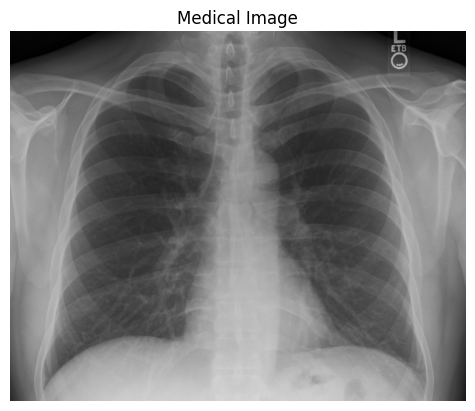

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Okay, here's a description of the chest X-ray based on the image you provided:

**Overall Impression:**

The chest X-ray shows a normal adult male. The lungs appear clear, and there are no obvious signs of acute pathology.

**Specific Findings:**

*   **Heart Size:** The heart size appears within normal limits.
*   **Mediastinum:** The mediastinum (the space between the lungs containing the heart, great vessels, trachea, etc.) is unremarkable.
*   **Lungs:** The lungs are clear bilaterally. There are no focal consolidations, effusions, or pneumothorax.
*   **Bones:** The ribs, clavicles, and spine appear intact.
*   **Soft Tissues:** The soft tissues of the chest wall are unremarkable.
*   **Diaphragm:** The diaphragms are well-defined.

**In summary:**

The chest X-ray is normal.

**Important Considerations:**

*   This is a single image, and a complete evaluation would require a full history and physical examination.
*   The absence of findings does not rule out all possible conditio

In [ ]:
from transformers import pipeline
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    device="cuda" if torch.cuda.is_available() else "cpu",
)

image_url = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
image = Image.open(requests.get(image_url, headers={"User-Agent": "example"}, stream=True).raw)


plt.imshow(image)
plt.axis("off")
plt.title("Medical Image")
plt.show()

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are an expert radiologist."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Describe According this X-ray"},
            {"type": "image", "image": image},
        ]
    }
]

output = pipe(text=messages, max_new_tokens=512)
print(output[0]["generated_text"][-1]["content"])

# ***Taking another example of a sonography image of a mother after childbirth and providing appropriate food precautions.***

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

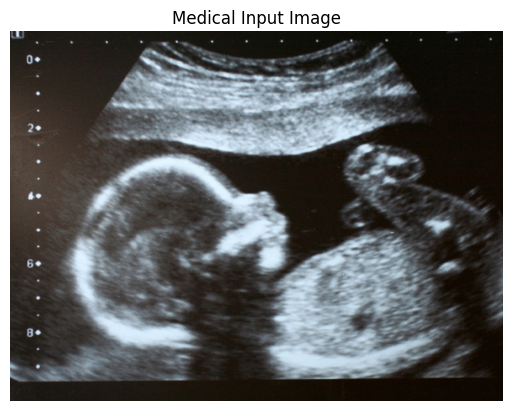

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1.  **Image Type Identification:** Ultrasound image of a fetus.

2.  **Key Observations:** The image shows a fetus with visible organs, including the brain, heart, and other internal structures.

3.  **Possible Condition (if any):** Based on the image, it is difficult to determine the specific condition of the fetus without additional information. However, it appears to be a normal development.

4.  **Weekly Food Precaution Plan (Veg):**

    *   **Monday:** Moong Dal Khichdi (Yellow split lentil porridge)
    *   **Tuesday:** Vegetable Upma (Semolina porridge with vegetables)
    *   **Wednesday:** Besan Chilla (Chickpea flour pancake with vegetables)
    *   **Thursday:** Aloo Gobi (Potato and cauliflower curry)
    *   **Friday:** Palak Paneer (Spinach and cottage cheese curry)
    *   **Saturday:** Vegetable Biryani (Rice dish with vegetables)
    *   **Sunday:** Dal Tadka (Lentil curry with spices)

5.  **General Lifestyle Advice:**

    *   Rest and relaxation are crucial during 

In [ ]:
from transformers import pipeline
from PIL import Image
import torch
import matplotlib.pyplot as plt


pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    device="cuda" if torch.cuda.is_available() else "cpu",
)

def analyze_image(image_path):
    image = Image.open(image_path).convert("RGB")


    plt.imshow(image)
    plt.axis("off")
    plt.title("Medical Input Image")
    plt.show()

    messages = [
     {
        "role": "system",
        "content": [{
            "type": "text",
            "text": (
                "You are a professional medical and diet assistant.\n\n"

                "First analyze the given medical image and then provide a diet plan.\n\n"

                "Follow this structure strictly:\n"
                "1. Image Type Identification\n"
                "2. Key Observations\n"
                "3. Possible Condition (if any)\n\n"

                "4. Weekly Food Precaution Plan (IMPORTANT):\n"
                "- Provide 7 days diet (Monday to Sunday)\n"
                "- Only ONE dish per day\n"
                "- Dishes should be simple and suitable for Indian diet\n"
                "- Ensure food matches the detected condition\n\n"

                "5. General Lifestyle Advice\n\n"

                "Rules:\n"
                "- Keep answers simple and clear\n"
                "- Do not give unsafe medical advice\n"
                "- If unsure, say 'uncertain'\n"
            )
         }]
       },
      {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Analyze this medical image and provide a weekly food precaution plan (one dish per day) and Only Provide Veg dish."
            },
            {"type": "image", "image": image},
        ]
      }
    ]

    output = pipe(text=messages, max_new_tokens=500)
    print(output[0]["generated_text"][-1]["content"])


analyze_image(r"/content/baby_sonography.jpg")


# ***Apply Better Prompt Technique And Provide Food Precaution***

In [ ]:
from IPython.display import display, Markdown


prompt = """
Create a detailed 7-day Food Precaution Plan for a patient suffering from high fever and stomach infection.

Requirements:
- Follow Indian vegetarian diet only
- Provide plan for each day (Monday to Sunday)
- For each day include:
  1. Breakfast
  2. Lunch
  3. Dinner
  4. Snacks (optional)
- Food should be:
  - Light
  - Easy to digest
  - Low oil and low spice
- Avoid harmful foods and mention what to avoid
- Keep language simple and easy to understand
- Maintain variety (do not repeat same meals every day)
- Add short reason why food is suitable

At the end:
- Add general precautions
- Ask 1–2 follow-up questions to user
"""

#System Instruction
system_instruction = """
You are a professional medical diet assistant specialized in Indian vegetarian diets.

Rules:
- Always give structured output
- Use clear headings for each day
- Use bullet points
- Keep explanation simple (non-technical)
- Focus on recovery from fever and stomach infection
- Ensure food is safe, hygienic, and easy to digest
- Avoid repetition of meals
- Be practical for Indian households
"""

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": system_instruction}]
    },
    {
        "role": "user",
        "content": [{"type": "text", "text": prompt}]
    }
]

output = pipe(messages, max_new_tokens=800)
response = output[0]["generated_text"][-1]["content"]

display(Markdown(f"\n\n---\n\n**[ User ]**\n\n{prompt}\n\n---\n\n"))
display(Markdown(f"**[ MedGemma ]**\n\n{response}\n\n---\n\n"))

Both `max_new_tokens` (=800) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




---

**[ User ]**


Create a detailed 7-day Food Precaution Plan for a patient suffering from high fever and stomach infection.

Requirements:
- Follow Indian vegetarian diet only
- Provide plan for each day (Monday to Sunday)
- For each day include:
  1. Breakfast
  2. Lunch
  3. Dinner
  4. Snacks (optional)
- Food should be:
  - Light
  - Easy to digest
  - Low oil and low spice
- Avoid harmful foods and mention what to avoid
- Keep language simple and easy to understand
- Maintain variety (do not repeat same meals every day)
- Add short reason why food is suitable

At the end:
- Add general precautions
- Ask 1–2 follow-up questions to user


---



**[ MedGemma ]**

Okay, here's a 7-day food plan designed to help you recover from a high fever and stomach infection, focusing on Indian vegetarian options that are light, easy to digest, and low in oil and spice.

**Important Note:** This is a general plan. If your symptoms worsen or you have any underlying health conditions, please consult your doctor or a registered dietitian for personalized advice.

**General Precautions:**

*   **Hydration is Key:** Drink plenty of fluids like water, clear broths, herbal teas (ginger, chamomile), and diluted fruit juices (apple, orange) throughout the day.
*   **Rest:** Get adequate rest to allow your body to heal.
*   **Hygiene:** Wash your hands frequently with soap and water, especially before eating and after using the toilet.
*   **Avoid Irritants:** Stay away from alcohol, caffeine, and sugary drinks, as they can worsen dehydration and upset your stomach.
*   **Listen to Your Body:** Eat when you feel hungry and stop when you're full. Don't force yourself to eat if you're not feeling up to it.

**7-Day Food Plan**

**Monday**

*   **Breakfast:**
    *   **Option 1:** *Upma* (made with semolina, vegetables like carrots and peas, and a little water)
    *   **Option 2:** *Poha* (flattened rice cooked with onions, potatoes, and a touch of lemon juice)
    *   **Why:** *Upma* and *Poha* are light and easy to digest. The vegetables add nutrients.
*   **Lunch:**
    *   **Option 1:** *Khichdi* (rice and lentil porridge, cooked with vegetables like carrots and beans)
    *   **Option 2:** *Dal* (lentil soup, made with mild spices like turmeric and cumin) with *Roti* (whole wheat flatbread)
    *   **Why:** *Khichdi* is very easy to digest, especially when cooked with plenty of water. *Dal* is a good source of protein and fiber.
*   **Dinner:**
    *   **Option 1:** *Vegetable Soup* (made with a variety of vegetables like spinach, tomatoes, and potatoes, cooked in a light broth)
    *   **Option 2:** *Roti* with *Bhindi Masala* (okra cooked with a little ginger and garlic)
    *   **Why:** Soup is hydrating and provides nutrients. *Bhindi Masala* is a mild and easily digestible vegetable dish.
*   **Snacks (Optional):**
    *   *Slices of Boiled Potato*
    *   *Small bowl of Yogurt*

**Tuesday**

*   **Breakfast:**
    *   **Option 1:** *Idli* (steamed rice cakes) with *Sambar* (lentil-based vegetable stew)
    *   **Option 2:** *Dosa* (thin rice crepe) with *Sambar*
    *   **Why:** *Idli* and *Dosa* are light and easy to digest. *Sambar* provides fiber and nutrients.
*   **Lunch:**
    *   **Option 1:** *Vegetable Biryani* (made with basmati rice, vegetables, and a minimal amount of ghee)
    *   **Option 2:** *Dal Makhani* (black lentil stew, made with a small amount of butter and cream) with *Roti*
    *   **Why:** *Vegetable Biryani* is a flavorful and nutritious option. *Dal Makhani* is a rich dish, but the small amount of butter and cream makes it more tolerable.
*   **

---



In [ ]:
! pip install langdetect

In [ ]:
!pip uninstall transformers -y
!pip install transformers==4.40.0

Found existing installation: transformers 4.40.0
Uninstalling transformers-4.40.0:
  Successfully uninstalled transformers-4.40.0
  Using cached transformers-4.40.0-py3-none-any.whl.metadata (137 kB)
Using cached transformers-4.40.0-py3-none-any.whl (9.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


# ***Convert the generated output into multiple languages according to the user's preference, including Hindi, Gujarati, Tamil, and others.***

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

class SimpleTranslator:
    def __init__(self):
        model_name = "ai4bharat/indictrans2-en-indic-1B"

        print("Loading translation model...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self.device)

        # Supported languages
        self.lang_map = {
            "english": "eng_Latn",
            "hindi": "hin_Deva",
            "tamil": "tam_Taml",
            "telugu": "tel_Telu",
            "marathi": "mar_Deva",
            "gujarati": "guj_Gujr",
            "bengali": "ben_Beng",
            "kannada": "kan_Knda",
        }

    def translate(self, text, target_lang):
        target_lang = target_lang.lower()

        if target_lang not in self.lang_map:
            print("Language not supported, defaulting to Hindi")
            target_lang = "hindi"

        src_code = self.lang_map["english"]
        tgt_code = self.lang_map[target_lang]

        formatted_text = f"{src_code} {tgt_code} {text}"

        inputs = self.tokenizer(
            formatted_text,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        outputs = self.model.generate(
          **inputs,
          max_length=300,              # reduce length
          num_beams=4,
          repetition_penalty=2.5,
          no_repeat_ngram_size=3,
          early_stopping=True
        )

        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)



if __name__ == "__main__":
    translator = SimpleTranslator()


    medical_output = """
     * Monday:** Moong Dal Khichdi (Yellow split lentil porridge)
     * Tuesday:** Vegetable Upma (Semolina porridge with vegetables)
     * Wednesday:** Besan Chilla (Chickpea flour pancake with vegetables)
     * Thursday:** Aloo Gobi (Potato and cauliflower curry)
     * Friday:** Palak Paneer (Spinach and cottage cheese curry)
     * Saturday:** Vegetable Biryani (Rice dish with vegetables)
     * Sunday:** Dal Tadka (Lentil curry with spices)
    """


    user_lang = input("Enter preferred language (Hindi, Tamil, Telugu, etc.): ")

    translated_text = translator.translate(medical_output, user_lang)

    print("\n===== TRANSLATED OUTPUT =====\n")
    print(translated_text)

Loading translation model...
The repository for ai4bharat/indictrans2-en-indic-1B contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ai4bharat/indictrans2-en-indic-1B.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository for ai4bharat/indictrans2-en-indic-1B contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ai4bharat/indictrans2-en-indic-1B.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository for ai4bharat/indictrans2-en-indic-1B contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ai4bharat/indictrans2-en-indic-1B.
You can avoid this prompt in future by passing the argumen

# ***Based on the generated food plan, relevant images are displayed for each dish, ensuring clear visibility and easy understanding for every day.***

Dish for the Day: moong dal khichdi


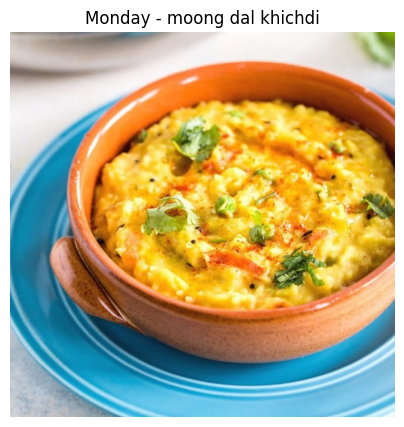

Dish for the Day: vegetable soup


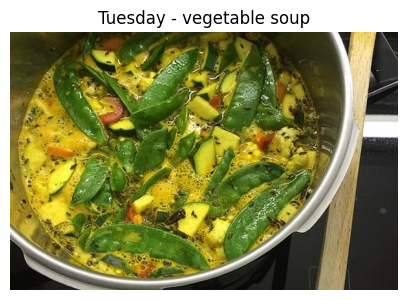

Dish for the Day: oats porridge


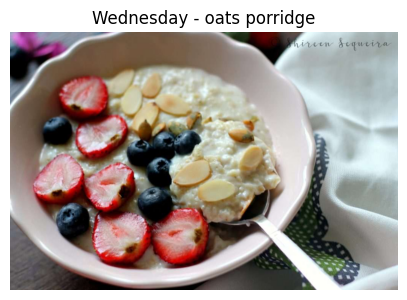

Dish for the Day: rice and chole


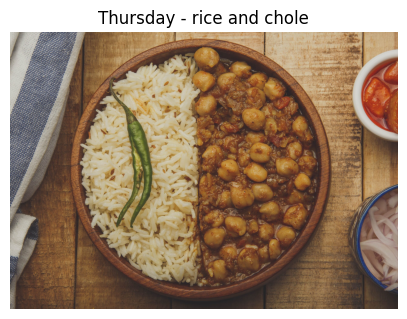

Dish for the Day: palak paneer


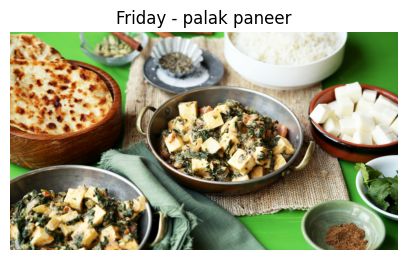

Dish for the Day: vegetable biryani


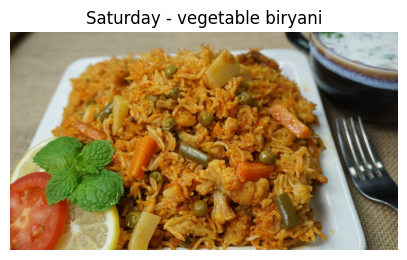

Dish for the Day: dal tadka


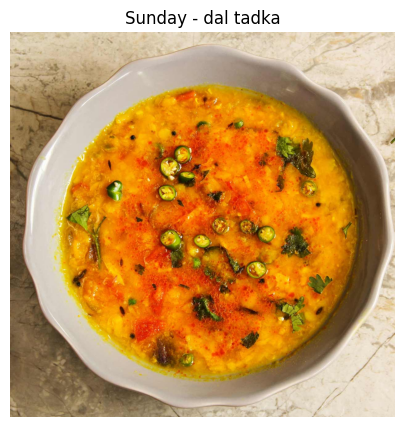

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from bs4 import BeautifulSoup
import urllib.parse
import json


text = """
Monday: moong dal khichdi
Tuesday: vegetable soup
Wednesday: oats porridge
Thursday: rice and chole
Friday: palak paneer
Saturday: vegetable biryani
Sunday: dal tadka
"""


lines = text.strip().split("\n")
food_plan = []

for line in lines:
    if ":" in line:
        day, dish = line.split(":", 1)
        food_plan.append((day.strip(), dish.strip()))


def fetch_hd_image(query):
    search_url = "https://www.bing.com/images/search?q=" + urllib.parse.quote(query)

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(search_url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")


    a_tags = soup.find_all("a", {"class": "iusc"})

    for a in a_tags:
        try:
            m_json = json.loads(a["m"])
            img_url = m_json["murl"]

            img_data = requests.get(img_url, headers=headers, timeout=5).content
            img = Image.open(BytesIO(img_data))

            return img
        except:
            continue

    return None


for day, dish in food_plan:
    print(f"Dish for the Day: {dish}")

    img = fetch_hd_image(dish + " indian food")

    if img:
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{day} - {dish}")
        plt.show()
    else:
        print(f"Image not found for {dish}")

In [ ]:
! pip install gtts langdetect playsound

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.5 MB/s eta 0:00:00
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=21f3b5f9b99bc32013b1e650738f65f78d3a97fb418853a0745426792e78e846
  Stored in directory: /root/.cache/pip/wheels/cf/42/ff/7c587bae55eec67b909ca316b250d9b4daedbf272a3cbeb907
Successfully built playsound
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


# ***The system implements text-to-speech conversion using gTTS, automatically detecting the language and generating audio output to enhance user accessibility and understanding.***

In [ ]:
from gtts import gTTS
from langdetect import detect
from IPython.display import Audio, display
from io import BytesIO

def speak(text):
    try:

        lang = detect(text)
        print("Detected Language:", lang)


        tts = gTTS(text=text, lang=lang)

        audio_bytes = BytesIO()
        tts.write_to_fp(audio_bytes)
        audio_bytes.seek(0)


        display(Audio(audio_bytes.read(), autoplay=True))

    except Exception as e:
        print("Error:", e)

# Test examples
speak("सोमवारः मूंग दाल खिचडी ( आलू और फूलगोभी की करी ) आलू गोबी ( आलू के साथ मटर का पैनकेक ) शुक्रवारः पालक पनीर ( पालक और कुटीर चीज़ों का करी ) शनिवारः सब्जी बिरयानी ( सब्जियों के साथ चावल का व्यंजन ) रविवारः दाल तड़का ( मसालों के साथ दलिया )")

Detected Language: hi


# ***Now, we will demonstrate a test example using Gujarati speech output.***

In [ ]:
from gtts import gTTS
from langdetect import detect
from IPython.display import Audio, display
from io import BytesIO

def speak(text):
    try:
        lang = detect(text)
        print("Detected Language:", lang)


        tts = gTTS(text=text, lang=lang)

        audio_bytes = BytesIO()
        tts.write_to_fp(audio_bytes)
        audio_bytes.seek(0)


        display(Audio(audio_bytes.read(), autoplay=True))

    except Exception as e:
        print("Error:", e)

# Test examples

speak("સોમવારઃ મૂંગ દાળ ખીચડી (આલૂ અને ફૂલકોબીની કરી) આલૂ ગોબી (આલૂ સાથે મટરનું પેન્કેક)શુક્રવારઃ પાલક પનીર (પાલક અને કોટેજ ચીઝની કરી)શનિવારઃ શાકભાજી બિરયાની (શાકભાજી સાથે ચોખાનો વાનગી)રવિવારઃ દાળ તડકો (મસાલાઓ સાથેની દાળ)")


Detected Language: gu
